In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

Tc = 2 / np.log(1 + np.sqrt(2))   # exact 2D Ising critical temperature
L_values = [10, 20, 30, 40, 60]

MODEL_DIR = 'models_100_op/models_100_op'
DATA_DIR  = 'data_decorr'

# Markers and colours matching the paper (light → dark with increasing L)
markers = ['x', '^', 'o', 'D', 's']
blues   = ['#c6dbef', '#9ecae1', '#6baed6', '#2171b5', '#08306b']   # ordered output
reds    = ['#fcbba1', '#fc9272', '#fb6a4a', '#cb181d', '#67000d']   # disordered output

In [2]:
results = {}   # results[L] = dict with keys 'T', 'out_ordered', 'out_disordered'
               #   each is an array over unique temperatures of the mean output

for L in L_values:
    # ── 1. Reconstruct same test split as model_creation_Ian.ipynb ──────────
    data    = np.load(f'{DATA_DIR}/L{L}_ising.npz')
    T_all   = data['temperatures']
    cfg_all = data['spins']

    rng = np.random.default_rng(seed=42)
    idx = np.arange(len(T_all))
    rng.shuffle(idx)

    # last 10 000 samples are the test set
    test_idx = idx[90000:]
    T_test   = T_all[test_idx]
    cfg_test = cfg_all[test_idx].astype(np.float32)

    # ── 2. Load model and run inference ────────────────────────────────────
    model = tf.keras.models.load_model(f'{MODEL_DIR}/ising_classifier_L{L}.h5')
    preds = model.predict(cfg_test, batch_size=512, verbose=0)   # shape (10000, 2)
    # label convention: [0] = P(T > Tc) = disordered, [1] = P(T < Tc) = ordered
    out_dis = preds[:, 0]
    out_ord = preds[:, 1]

    # ── 3. Average over test samples at each unique temperature ─────────────
    unique_T   = np.unique(T_test)
    mean_ord   = np.array([out_ord[T_test == t].mean() for t in unique_T])
    mean_dis   = np.array([out_dis[T_test == t].mean() for t in unique_T])

    results[L] = {'T': unique_T, 'ordered': mean_ord, 'disordered': mean_dis}
    print(f'L={L}: {len(unique_T)} unique temperatures, predictions done')

L=10: 40 unique temperatures, predictions done
L=20: 40 unique temperatures, predictions done


L=30: 40 unique temperatures, predictions done


L=40: 40 unique temperatures, predictions done


L=60: 40 unique temperatures, predictions done


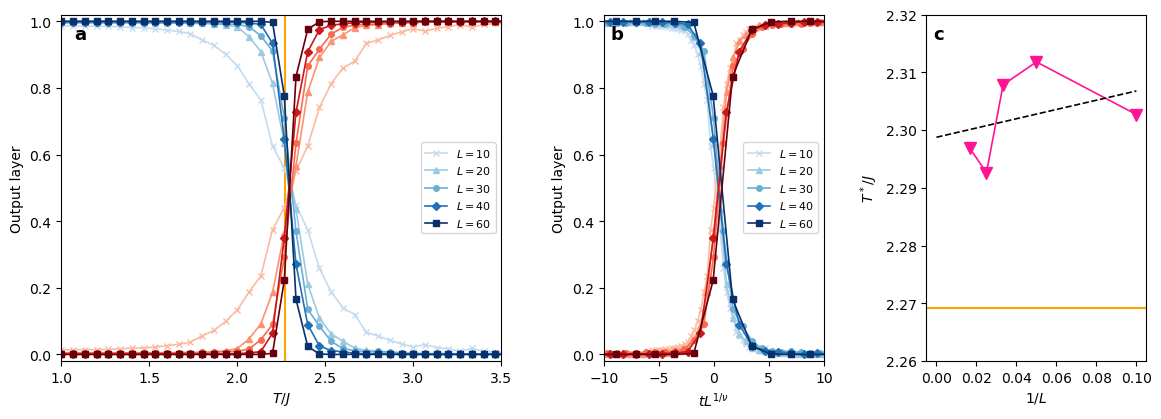

Extrapolated Tc (1/L→0): 2.2988   exact: 2.2692


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), gridspec_kw={'width_ratios': [2, 1, 1]})
fig.subplots_adjust(wspace=0.35)

# ── Panel a: output layer vs T/J ─────────────────────────────────────────
ax = axes[0]
for i, L in enumerate(L_values):
    T      = results[L]['T']
    ax.plot(T, results[L]['ordered'],    color=blues[i], marker=markers[i],
            ms=4, lw=1.2, label=f'$L={L}$')
    ax.plot(T, results[L]['disordered'], color=reds[i],  marker=markers[i],
            ms=4, lw=1.2)

ax.axvline(Tc, color='orange', lw=1.5, zorder=0)
ax.set_xlim(1.0, 3.5)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('$T/J$')
ax.set_ylabel('Output layer')
ax.legend(fontsize=8, loc='center right')
ax.text(0.03, 0.97, 'a', transform=ax.transAxes,
        fontsize=13, fontweight='bold', va='top')

# ── Panel b: data collapse  x = (T - Tc) / Tc * L^(1/nu), nu = 1 ────────
ax = axes[1]
nu = 1.0
for i, L in enumerate(L_values):
    T   = results[L]['T']
    t   = (T - Tc) / Tc          # reduced temperature
    x   = t * L ** (1 / nu)
    ax.plot(x, results[L]['ordered'],    color=blues[i], marker=markers[i],
            ms=4, lw=1.2, label=f'$L={L}$')
    ax.plot(x, results[L]['disordered'], color=reds[i],  marker=markers[i],
            ms=4, lw=1.2)

ax.set_xlim(-10, 10)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('$tL^{1/\\nu}$')
ax.set_ylabel('Output layer')
ax.legend(fontsize=8, loc='center right')
ax.text(0.03, 0.97, 'b', transform=ax.transAxes,
        fontsize=13, fontweight='bold', va='top')

# ── Panel c: crossing temperature T* vs 1/L ───────────────────────────────
ax = axes[2]
T_star = []
for L in L_values:
    T   = results[L]['T']
    ord_out = results[L]['ordered']
    # find T where ordered output = 0.5 by interpolation
    try:
        f    = interp1d(ord_out[::-1], T[::-1])   # ord_out decreases with T
        Tstar = float(f(0.5))
    except Exception:
        Tstar = np.nan
    T_star.append(Tstar)

inv_L  = 1 / np.array(L_values)
T_star = np.array(T_star)

ax.plot(inv_L, T_star, 'v', color='deeppink', ms=8, zorder=3)
ax.plot(inv_L, T_star, '-', color='deeppink', lw=1.2)

# dashed linear extrapolation to 1/L = 0
slope, intercept = np.polyfit(inv_L, T_star, 1)
x_fit = np.linspace(0, inv_L.max(), 100)
ax.plot(x_fit, np.polyval([slope, intercept], x_fit), 'k--', lw=1.2)

# horizontal line at exact Tc
ax.axhline(Tc, color='orange', lw=1.5, zorder=0)

ax.set_xlim(-0.005, 0.105)
ax.set_ylim(2.26, 2.32)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.set_xlabel('$1/L$')
ax.set_ylabel('$T^*/J$')
ax.text(0.03, 0.97, 'c', transform=ax.transAxes,
        fontsize=13, fontweight='bold', va='top')

#plt.savefig('figure1_abc.pdf', bbox_inches='tight', dpi=150)
plt.show()
print(f'Extrapolated Tc (1/L→0): {intercept:.4f}   exact: {Tc:.4f}')